In [9]:
import yaml
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

params_path = Path("../parameters/cyto_parameters.yaml")
with open(params_path) as f:
    params = yaml.safe_load(f)

pap = params["pap_per_day"]
non_pap = params["non_pap_per_day"]
case_complexity = params["case_complexity"]
slide_ratios = params["slide_pt_ratio_by_case_complexity"]

pap_lambda = pap["params"][0]
non_pap_lambda = non_pap["params"][0]
pap_slide_ratio = pap["slide_pt_ratio"]

expected_non_pap_slides_per_patient = (
    case_complexity["p_high"] * slide_ratios["high"]
    + (1 - case_complexity["p_high"]) * slide_ratios["low"]
)

def poisson_pmf(k, lam):
    k = np.asarray(k, dtype=float)
    return np.exp(k * np.log(lam) - lam - np.vectorize(math.lgamma)(k + 1))

def triangular_pdf(x, minimum, mode, maximum):
    x = np.asarray(x, dtype=float)
    pdf = np.zeros_like(x)
    left = (x >= minimum) & (x <= mode)
    right = (x > mode) & (x <= maximum)
    span = maximum - minimum
    pdf[left] = 2 * (x[left] - minimum) / (span * (mode - minimum))
    pdf[right] = 2 * (maximum - x[right]) / (span * (maximum - mode))
    return pdf

def triangular_mean(minimum, mode, maximum):
    return (minimum + mode + maximum) / 3

def plot_constant_service(ax, value, title, color, unit="min/batch"):
    ax.axvline(value, color=color, linewidth=3, label=f"Constant = {value} {unit}")
    ax.set_xlim(max(0, value - 15), value + 15)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(title)
    ax.set_xlabel("Time (minutes)")
    ax.legend(loc="upper right")
    ax.grid(axis="x", alpha=0.25)

def plot_triangular_by_complexity(ax, service_params, title, unit="min"):
    colors = {"high": "#E45756", "low": "#54A24B"}
    for complexity in ("high", "low"):
        cfg = service_params["by_case_complexity"][complexity]
        minimum, mode, maximum = cfg["params"]
        x = np.linspace(minimum, maximum, 300)
        pdf = triangular_pdf(x, minimum, mode, maximum)
        mean = triangular_mean(minimum, mode, maximum)
        ax.plot(
            x,
            pdf,
            color=colors[complexity],
            linewidth=2,
            label=f"{complexity}: [{minimum}, {mode}, {maximum}], mean={mean:.1f}",
        )
        ax.axvline(mean, color=colors[complexity], linestyle=":", alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel(f"Time ({unit})")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.25)


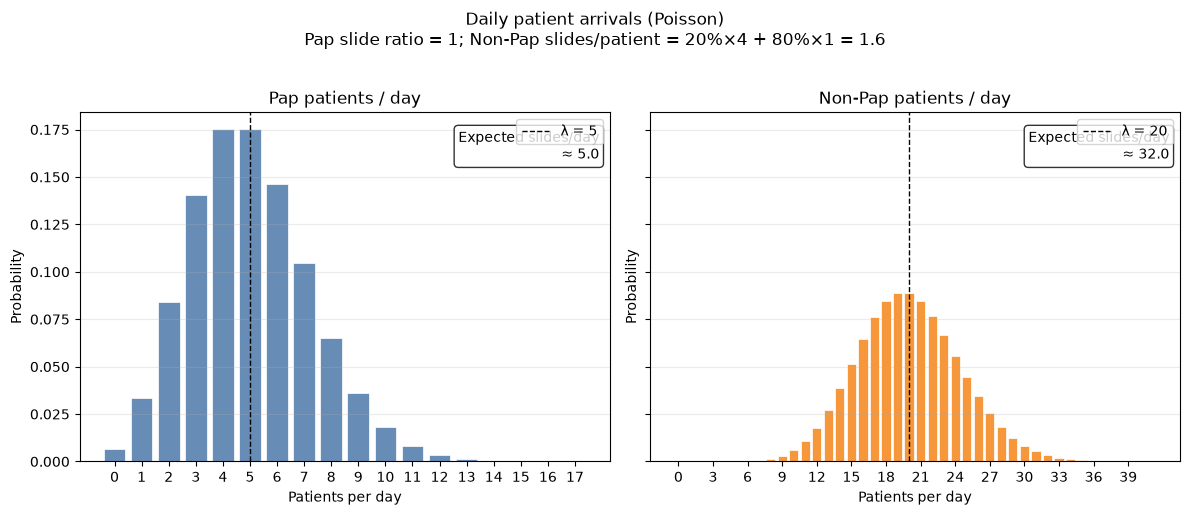

Expected total patients/day: 25
Expected total slides/day:   37.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

configs = [
    ("Pap patients / day", pap_lambda, pap_slide_ratio, "#4C78A8"),
    ("Non-Pap patients / day", non_pap_lambda, expected_non_pap_slides_per_patient, "#F58518"),
]

for ax, (title, lam, slide_ratio, color) in zip(axes, configs):
    k = np.arange(0, int(lam + 4 * np.sqrt(lam)) + 5)
    pmf = poisson_pmf(k, lam)

    ax.bar(k, pmf, color=color, alpha=0.85, edgecolor="white", linewidth=0.6)
    ax.axvline(lam, color="black", linestyle="--", linewidth=1, label=f"λ = {lam}")
    ax.set_title(title)
    ax.set_xlabel("Patients per day")
    ax.set_ylabel("Probability")
    ax.set_xticks(k[:: max(1, len(k) // 12)])
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right")

    expected_slides = lam * slide_ratio
    ax.text(
        0.98,
        0.95,
        f"Expected slides/day\n≈ {expected_slides:.1f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

fig.suptitle(
    "Daily patient arrivals (Poisson)\n"
    f"Pap slide ratio = {pap_slide_ratio}; "
    f"Non-Pap slides/patient = {case_complexity['p_high']:.0%}×{slide_ratios['high']} + "
    f"{1 - case_complexity['p_high']:.0%}×{slide_ratios['low']} = {expected_non_pap_slides_per_patient:.1f}",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

total_patients_lambda = pap_lambda + non_pap_lambda
expected_total_slides = pap_lambda * pap_slide_ratio + non_pap_lambda * expected_non_pap_slides_per_patient
print(f"Expected total patients/day: {total_patients_lambda}")
print(f"Expected total slides/day:   {expected_total_slides:.1f}")


Expected screening time (20% high / 80% low): 22.0 min
Expected reporting time (20% high / 80% low): 5.4 min


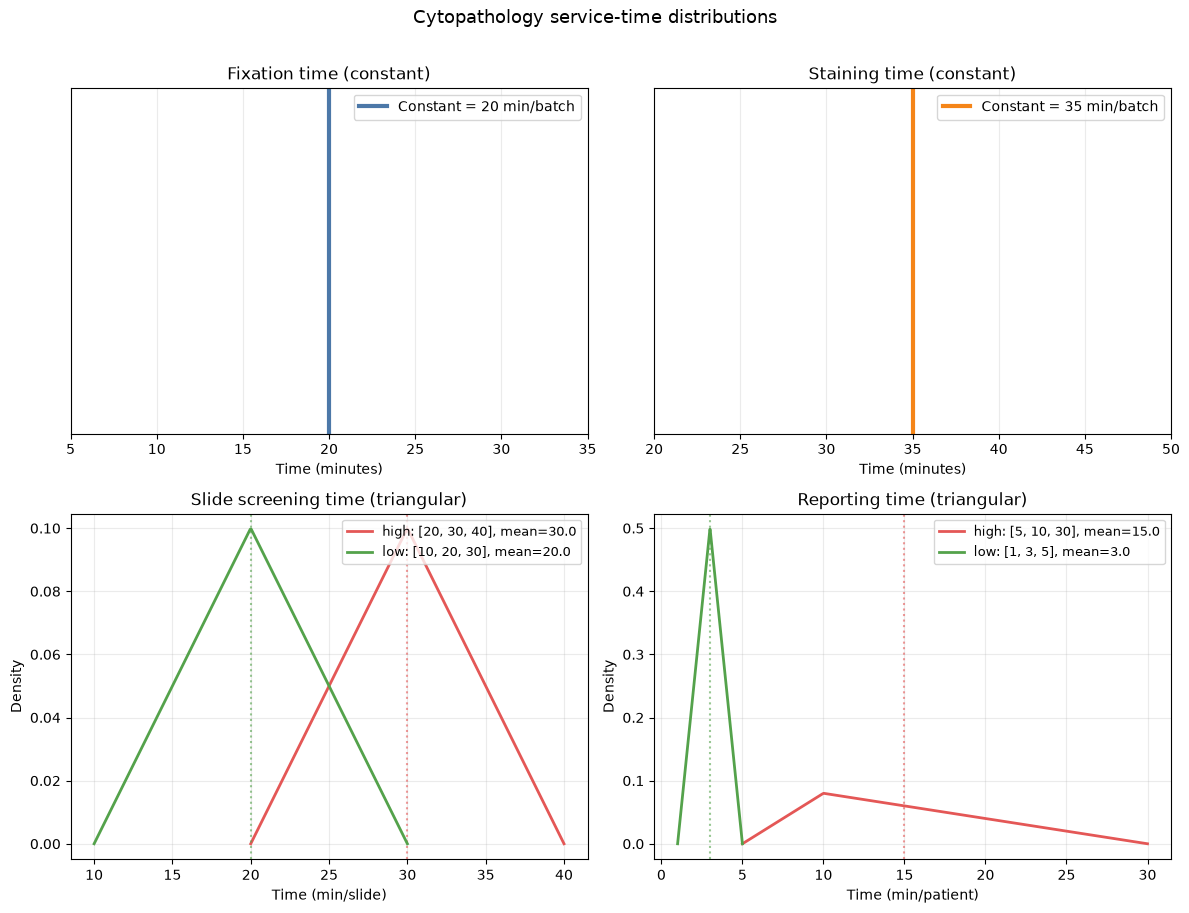

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

plot_constant_service(
    axes[0, 0],
    params["cyto_fixation_time"]["params"],
    "Fixation time (constant)",
    "#4C78A8",
)
plot_constant_service(
    axes[0, 1],
    params["cyto_staining_time"]["params"],
    "Staining time (constant)",
    "#F58518",
)
plot_triangular_by_complexity(
    axes[1, 0],
    params["cyto_slide_screening_time"],
    "Slide screening time (triangular)",
    unit="min/slide",
)
plot_triangular_by_complexity(
    axes[1, 1],
    params["cyto_reporting_time"],
    "Reporting time (triangular)",
    unit="min/patient",
)

p_high = case_complexity["p_high"]
for name, service in (
    ("screening", params["cyto_slide_screening_time"]),
    ("reporting", params["cyto_reporting_time"]),
):
    mixed_mean = sum(
        (p_high if c == "high" else 1 - p_high)
        * triangular_mean(*service["by_case_complexity"][c]["params"])
        for c in ("high", "low")
    )
    print(f"Expected {name} time ({p_high:.0%} high / {1 - p_high:.0%} low): {mixed_mean:.1f} min")

fig.suptitle("Cytopathology service-time distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
histo_path = Path("../parameters/histo_parameters.yaml")
with open(histo_path) as f:
    histo = yaml.safe_load(f)

cervical = histo["cervical_biopsies_per_day"]
other = histo["other_biopsies_per_day"]
histo_case_complexity = histo["case_complexity"]
slide_ratios_by_size = histo["slide_pt_ratio_by_biopsy_size"]
biopsy_weights = histo["biopsy_size"]["weights"]

cervical_lambda = cervical["params"][0]
other_lambda = other["params"][0]

sizes = ["small", "medium", "large"]
weights = np.array([biopsy_weights[s] for s in sizes], dtype=float)
weights = weights / weights.sum()
slides_by_size = np.array([slide_ratios_by_size[s] for s in sizes], dtype=float)
expected_slides_per_patient = float(np.dot(weights, slides_by_size))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# --- Top row: Poisson patient arrivals ---
arrival_configs = [
    ("Cervical biopsies / day", cervical_lambda, "#4C78A8"),
    ("Other biopsies / day", other_lambda, "#F58518"),
]
for ax, (title, lam, color) in zip(axes[0], arrival_configs):
    k = np.arange(0, int(lam + 4 * np.sqrt(lam)) + 5)
    pmf = poisson_pmf(k, lam)
    ax.bar(k, pmf, color=color, alpha=0.85, edgecolor="white", linewidth=0.6)
    ax.axvline(lam, color="black", linestyle="--", linewidth=1, label=f"λ = {lam}")
    ax.set_title(title)
    ax.set_xlabel("Patients per day")
    ax.set_ylabel("Probability")
    ax.set_xticks(k[:: max(1, len(k) // 12)])
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right", fontsize=9)
    ax.text(
        0.98,
        0.95,
        f"Expected patients/day = {lam}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

# --- Bottom left: biopsy size weights ---
colors_size = {"small": "#54A24B", "medium": "#F58518", "large": "#E45756"}
ax_w = axes[1, 0]
bars = ax_w.bar(
    sizes,
    weights,
    color=[colors_size[s] for s in sizes],
    edgecolor="white",
    alpha=0.9,
)
ax_w.set_title("Biopsy size distribution")
ax_w.set_xlabel("Biopsy size")
ax_w.set_ylabel("Probability")
ax_w.set_ylim(0, 1)
for bar, w in zip(bars, weights):
    ax_w.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{w:.0%}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax_w.grid(axis="y", alpha=0.25)

# --- Bottom right: slides per patient by size ---
ax_s = axes[1, 1]
bars = ax_s.bar(
    sizes,
    slides_by_size,
    color=[colors_size[s] for s in sizes],
    edgecolor="white",
    alpha=0.9,
)
ax_s.set_title("Slides (blocks) per patient by biopsy size")
ax_s.set_xlabel("Biopsy size")
ax_s.set_ylabel("Slides per patient")
for bar, n in zip(bars, slides_by_size):
    ax_s.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(n)),
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax_s.grid(axis="y", alpha=0.25)
ax_s.text(
    0.98,
    0.95,
    f"Expected slides/patient\n≈ {expected_slides_per_patient:.2f}",
    transform=ax_s.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

p_high = histo_case_complexity["p_high"]
total_patients_lambda = cervical_lambda + other_lambda
expected_total_slides = total_patients_lambda * expected_slides_per_patient

fig.suptitle(
    "Histopathology workload parameters\n"
    f"Case complexity: {p_high:.0%} high / {1 - p_high:.0%} low",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"Expected cervical patients/day:     {cervical_lambda}")
print(f"Expected other biopsy patients/day: {other_lambda}")
print(f"Expected total patients/day:        {total_patients_lambda}")
print(f"Expected slides/patient (weighted): {expected_slides_per_patient:.2f}")
print(f"Expected total slides/day:          {expected_total_slides:.1f}")
